# Analyzing the Influence of Social Media Trends on Public Health Awareness

**Student:** Abdelaziz Ouattara  
**Course:** DSC 680 Applied Data Science  
**Project:** Milestone 3 Final Project  
**Dataset:** COVID-19 Tweets Dataset  

This Jupyter Notebook presents the final applied data science project for DSC 680. The project analyzes COVID-19 related tweets to examine public sentiment, communication patterns, and implications for public health awareness.

## Abstract

Social media has become a major channel for public health communication, especially during public health emergencies such as the COVID-19 pandemic. Platforms such as Twitter allow users, organizations, and public officials to rapidly share information, opinions, concerns, and misinformation. This project analyzes a COVID-19 tweets dataset to evaluate how public health topics were discussed on social media and what sentiment patterns emerged from those discussions. The project uses Python-based data science methods, including data cleaning, exploratory data analysis, text preprocessing, sentiment analysis, TF-IDF feature engineering, and machine learning classification. Sentiment polarity is estimated using TextBlob, and classification models are trained to predict sentiment categories from tweet text. The analysis provides insight into public reactions, frequently used words and hashtags, tweet activity patterns over time, and ethical concerns related to using publicly available social media data. The results demonstrate how social media analytics can support public health communication strategies while also requiring careful attention to privacy, bias, representativeness, and responsible interpretation.

## Introduction

The COVID-19 pandemic demonstrated the importance of timely, accurate, and accessible public health communication. During the pandemic, millions of individuals used Twitter to share personal experiences, respond to public health guidance, discuss vaccines and prevention measures, and spread both accurate information and misinformation. Because of its real-time nature, Twitter data can provide useful insight into public awareness and public sentiment around health issues.

Public health agencies can benefit from understanding social media trends because online conversations may reveal public concerns faster than traditional surveys or formal reporting systems. However, social media data also has limitations. Twitter users do not represent the entire population, and posts may contain sarcasm, emotional language, misinformation, or incomplete context. Therefore, social media analytics should be used as a complementary tool rather than as a replacement for traditional public health research.

This project applies natural language processing and machine learning methods to COVID-19 related tweets. The goal is to examine tweet content, identify sentiment patterns, visualize trends, and evaluate whether machine learning models can classify tweet sentiment based on text features.

## Research Questions

This project is guided by the following research questions:

1. What is the overall sentiment distribution of COVID-19 related tweets?
2. Which words and hashtags appear most frequently in COVID-19 related tweets?
3. How does tweet activity change over time?
4. Can tweet text be used to classify sentiment using machine learning models?
5. What ethical concerns arise when using publicly available social media data for public health research?

## Import Libraries

The following libraries are used for data loading, cleaning, visualization, natural language processing, sentiment analysis, and machine learning.

In [3]:
import warnings
warnings.filterwarnings("ignore")

import re
import ast
import string
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from textblob import TextBlob
except ImportError:
    TextBlob = None
    print("TextBlob is not installed. Install it with: pip install textblob")

try:
    from wordcloud import WordCloud
except ImportError:
    WordCloud = None
    print("wordcloud is not installed. Install it with: pip install wordcloud")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Load Dataset

The dataset used for this project is `covid19_tweets.csv`. It contains tweets related to COVID-19 and includes tweet text, date, hashtags, source, and user-level metadata.

In [4]:
file_path = "covid19_tweets.csv"

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    df = pd.read_csv(r"C:\Users\OUA\OneDrive\Desktop\School\DSC680\W4\Final_Project\covid19_tweets.csv")

print("Dataset loaded successfully.")
print("Rows and columns:", df.shape)
df.head()

Dataset loaded successfully.
Rows and columns: (179108, 13)


,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,is_retweet
0,ᏉᎥ☻լꂅϮ,astroworld,wednesday addams as a disney princess keepin it [̲̅$̲̅(̲̅ιοο̲̅)̲̅$̲̅] 👸🏻💚♊️🧀🌵🌃🌙,2017-05-26 05:46:42,624,950,18775,False,2020-07-25 12:27:21,"If I smelled the scent of hand sanitizers today on someone in the past, I would think they were so intoxicated that…...",NaN,Twitter for iPhone,False
1,Tom Basile 🇺🇸,"New York, NY","Husband, Father, Columnist & Commentator. Author of Tough Sell: Fighting the Media War in Iraq. Bush Admin Alum. New...",2009-04-16 20:06:23,2253,1677,24,True,2020-07-25 12:27:17,Hey @Yankees @YankeesPR and @MLB - wouldn't it have made more sense to have the players pay their respects to the A…...,NaN,Twitter for Android,False
2,Time4fisticuffs,"Pewee Valley, KY",#Christian #Catholic #Conservative #Reagan #Republican #Capitalist; Sports lover - #BBN #Cincinnati #Reds #Bengals #...,2009-02-28 18:57:41,9275,9525,7254,False,2020-07-25 12:27:14,@diane3443 @wdunlap @realDonaldTrump Trump never once claimed #COVID19 was a hoax. We all claim that this effort to…...,['COVID19'],Twitter for Android,False
3,ethel mertz,Stuck in the Middle,#Browns #Indians #ClevelandProud #[]_[] #Cavs #Resist,2019-03-07 01:45:06,197,987,1488,False,2020-07-25 12:27:10,@brookbanktv The one gift #COVID19 has give me is an appreciation for the simple things that were always around me… ...,['COVID19'],Twitter for iPhone,False
4,DIPR-J&K,Jammu and Kashmir,"🖊️Official Twitter handle of Department of Information and Public Relations, Govt of Jammu & Kashmir",2017-02-12 06:45:15,101009,168,101,False,2020-07-25 12:27:08,25 July : Media Bulletin on Novel #CoronaVirusUpdates #COVID19 \n@kansalrohit69 @DrSyedSehrish @airnewsalerts @ANI… ...,"['CoronaVirusUpdates', 'COVID19']",Twitter for Android,False


## Dataset Overview

This section reviews the structure of the dataset, including columns, data types, missing values, and a sample of records.

In [5]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Column names:
['user_name', 'user_location', 'user_description', 'user_created', 'user_followers', 'user_friends', 'user_favourites', 'user_verified', 'date', 'text', 'hashtags', 'source', 'is_retweet']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 179108 entries, 0 to 179107
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   user_name         179108 non-null  object
 1   user_location     142337 non-null  object
 2   user_description  168822 non-null  object
 3   user_created      179108 non-null  object
 4   user_followers    179108 non-null  int64 
 5   user_friends      179108 non-null  int64 
 6   user_favourites   179108 non-null  int64 
 7   user_verified     179108 non-null  bool  
 8   date              179108 non-null  object
 9   text              179108 non-null  object
 10  hashtags          127774 non-null  object
 11  source            179031 non-null  object
 12  i

In [6]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percent": missing_percent.round(2)
})

missing_summary

,missing_count,missing_percent
hashtags,51334,28.66
user_location,36771,20.53
user_description,10286,5.74
source,77,0.04
user_name,0,0.00
user_created,0,0.00
user_followers,0,0.00
user_friends,0,0.00
user_favourites,0,0.00
user_verified,0,0.00


In [7]:
df.describe(include="all").T.head(30)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_name,179108,92276,GlobalPandemic.NET,679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_location,142337,26920,India,3741,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_description,168822,89200,Breaking News & Critical Information to SURVIVE the Coronavirus Outbreak / Civil Unrest,679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_created,179108,93708,2010-07-13 21:58:05,679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_followers,179108.0,NaN,NaN,NaN,109055.528184,841467.000703,0.0,172.0,992.0,5284.0,49442559.0
user_friends,179108.0,NaN,NaN,NaN,2121.701566,9162.553072,0.0,148.0,542.0,1725.25,497363.0
user_favourites,179108.0,NaN,NaN,NaN,14444.105663,44522.698958,0.0,206.0,1791.0,9388.0,2047197.0
user_verified,179108,2,False,156013,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,179108,136611,2020-08-06 16:00:00,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,179108,178683,"The incompetence of this administration, and the president in particular, has doomed us all. This is Trump's pandemi...",13,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

The data cleaning process includes removing duplicate tweets, handling missing tweet text, converting date fields to datetime format, and creating simplified date variables for time-based analysis.

In [8]:
df_clean = df.copy()

# Remove duplicate rows
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print("Duplicate rows removed:", initial_rows - len(df_clean))

# Remove rows with missing tweet text
df_clean = df_clean.dropna(subset=["text"])

# Convert text to string
df_clean["text"] = df_clean["text"].astype(str)

# Convert date column to datetime
df_clean["date"] = pd.to_datetime(df_clean["date"], errors="coerce")
df_clean = df_clean.dropna(subset=["date"])

# Create date features
df_clean["tweet_date"] = df_clean["date"].dt.date
df_clean["tweet_month"] = df_clean["date"].dt.to_period("M").astype(str)
df_clean["tweet_day_name"] = df_clean["date"].dt.day_name()
df_clean["tweet_hour"] = df_clean["date"].dt.hour

print("Cleaned dataset shape:", df_clean.shape)
df_clean.head()

Duplicate rows removed: 0
Cleaned dataset shape: (179108, 17)


,user_name,user_location,user_description,user_created,user_followers,user_friends,user_favourites,user_verified,date,text,hashtags,source,is_retweet,tweet_date,tweet_month,tweet_day_name,tweet_hour
0,ᏉᎥ☻լꂅϮ,astroworld,wednesday addams as a disney princess keepin it [̲̅$̲̅(̲̅ιοο̲̅)̲̅$̲̅] 👸🏻💚♊️🧀🌵🌃🌙,2017-05-26 05:46:42,624,950,18775,False,2020-07-25 12:27:21,"If I smelled the scent of hand sanitizers today on someone in the past, I would think they were so intoxicated that…...",NaN,Twitter for iPhone,False,2020-07-25,2020-07,Saturday,12
1,Tom Basile 🇺🇸,"New York, NY","Husband, Father, Columnist & Commentator. Author of Tough Sell: Fighting the Media War in Iraq. Bush Admin Alum. New...",2009-04-16 20:06:23,2253,1677,24,True,2020-07-25 12:27:17,Hey @Yankees @YankeesPR and @MLB - wouldn't it have made more sense to have the players pay their respects to the A…...,NaN,Twitter for Android,False,2020-07-25,2020-07,Saturday,12
2,Time4fisticuffs,"Pewee Valley, KY",#Christian #Catholic #Conservative #Reagan #Republican #Capitalist; Sports lover - #BBN #Cincinnati #Reds #Bengals #...,2009-02-28 18:57:41,9275,9525,7254,False,2020-07-25 12:27:14,@diane3443 @wdunlap @realDonaldTrump Trump never once claimed #COVID19 was a hoax. We all claim that this effort to…...,['COVID19'],Twitter for Android,False,2020-07-25,2020-07,Saturday,12
3,ethel mertz,Stuck in the Middle,#Browns #Indians #ClevelandProud #[]_[] #Cavs #Resist,2019-03-07 01:45:06,197,987,1488,False,2020-07-25 12:27:10,@brookbanktv The one gift #COVID19 has give me is an appreciation for the simple things that were always around me… ...,['COVID19'],Twitter for iPhone,False,2020-07-25,2020-07,Saturday,12
4,DIPR-J&K,Jammu and Kashmir,"🖊️Official Twitter handle of Department of Information and Public Relations, Govt of Jammu & Kashmir",2017-02-12 06:45:15,101009,168,101,False,2020-07-25 12:27:08,25 July : Media Bulletin on Novel #CoronaVirusUpdates #COVID19 \n@kansalrohit69 @DrSyedSehrish @airnewsalerts @ANI… ...,"['CoronaVirusUpdates', 'COVID19']",Twitter for Android,False,2020-07-25,2020-07,Saturday,12


## Text Cleaning Function

Tweets often contain URLs, mentions, hashtags, punctuation, emojis, numbers, and repeated whitespace. The following function cleans tweet text for analysis while preserving meaningful words.

In [9]:
def clean_tweet_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_clean["clean_text"] = df_clean["text"].apply(clean_tweet_text)
df_clean["tweet_length"] = df_clean["text"].apply(len)
df_clean["clean_text_length"] = df_clean["clean_text"].apply(len)

df_clean[["text", "clean_text", "tweet_length", "clean_text_length"]].head()

,text,clean_text,tweet_length,clean_text_length
0,"If I smelled the scent of hand sanitizers today on someone in the past, I would think they were so intoxicated that…...",if i smelled the scent of hand sanitizers today on someone in the past i would think they were so intoxicated that…,140,115
1,Hey @Yankees @YankeesPR and @MLB - wouldn't it have made more sense to have the players pay their respects to the A…...,hey and wouldnt it have made more sense to have the players pay their respects to the a…,140,88
2,@diane3443 @wdunlap @realDonaldTrump Trump never once claimed #COVID19 was a hoax. We all claim that this effort to…...,trump never once claimed covid was a hoax we all claim that this effort to…,140,75
3,@brookbanktv The one gift #COVID19 has give me is an appreciation for the simple things that were always around me… ...,the one gift covid has give me is an appreciation for the simple things that were always around me…,139,99
4,25 July : Media Bulletin on Novel #CoronaVirusUpdates #COVID19 \n@kansalrohit69 @DrSyedSehrish @airnewsalerts @ANI… ...,july media bulletin on novel coronavirusupdates covid …,138,55


## Exploratory Data Analysis

Exploratory data analysis helps identify patterns in the dataset before modeling. This section examines tweet volume, user activity, verification status, tweet length, and source distribution.

In [10]:
print("Number of tweets:", len(df_clean))
print("Number of unique users:", df_clean["user_name"].nunique())
print("Date range:", df_clean["date"].min(), "to", df_clean["date"].max())

Number of tweets: 179108
Number of unique users: 92276
Date range: 2020-07-24 23:47:08 to 2020-08-30 09:07:39


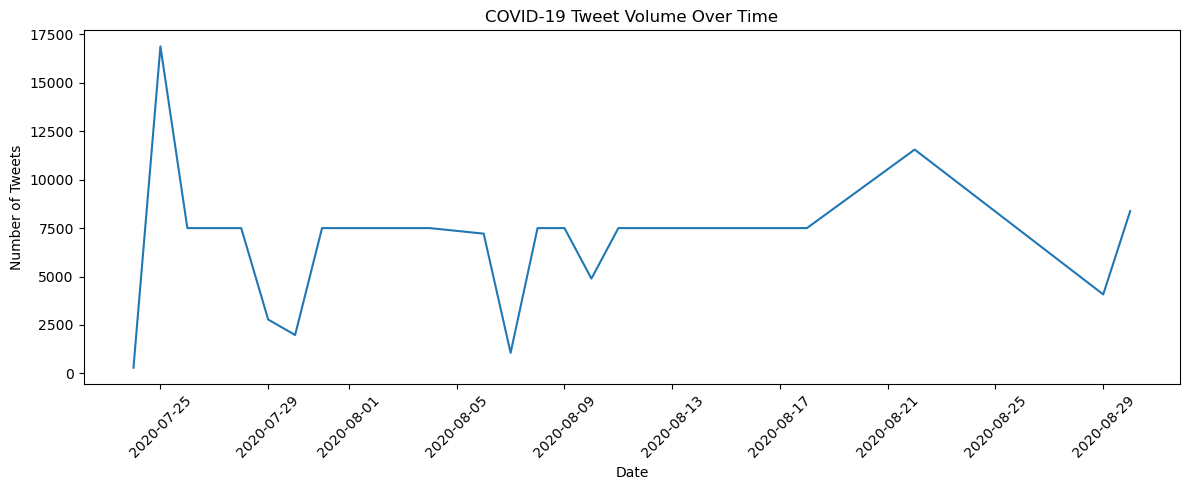

In [11]:
# Tweet volume over time
tweets_by_date = df_clean.groupby("tweet_date").size()

plt.figure(figsize=(12, 5))
tweets_by_date.plot()
plt.title("COVID-19 Tweet Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

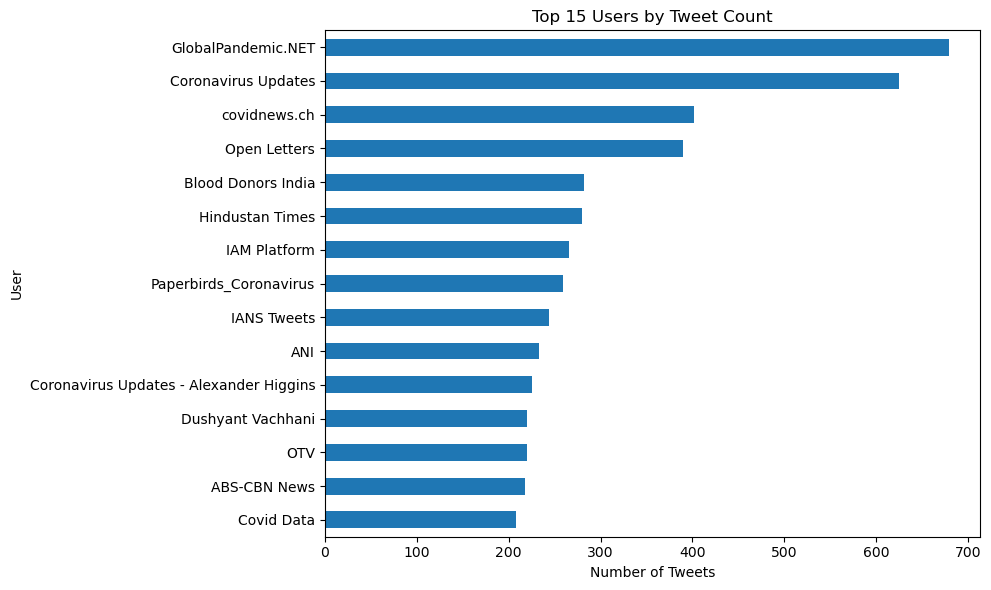

user_name
GlobalPandemic.NET                         679
Coronavirus Updates                        625
covidnews.ch                               402
Open Letters                               390
Blood Donors India                         282
Hindustan Times                            280
IAM Platform                               266
Paperbirds_Coronavirus                     259
IANS Tweets                                244
ANI                                        233
Coronavirus Updates - Alexander Higgins    225
OTV                                        220
Dushyant Vachhani                          220
ABS-CBN News                               218
Covid Data                                 208
Name: count, dtype: int64

In [12]:
# Top users by number of tweets
top_users = df_clean["user_name"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_users.sort_values().plot(kind="barh")
plt.title("Top 15 Users by Tweet Count")
plt.xlabel("Number of Tweets")
plt.ylabel("User")
plt.tight_layout()
plt.show()

top_users

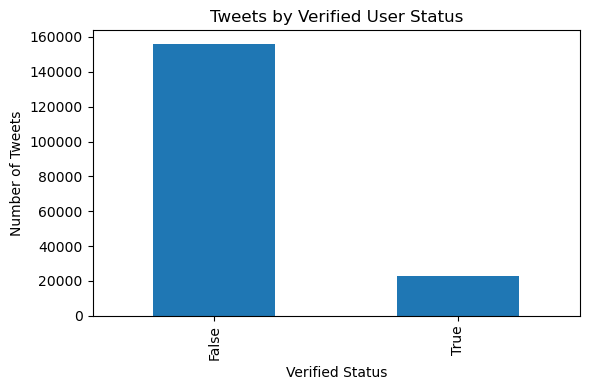

In [13]:
# Verified vs non-verified users
if "user_verified" in df_clean.columns:
    verified_counts = df_clean["user_verified"].value_counts()

    plt.figure(figsize=(6, 4))
    verified_counts.plot(kind="bar")
    plt.title("Tweets by Verified User Status")
    plt.xlabel("Verified Status")
    plt.ylabel("Number of Tweets")
    plt.tight_layout()
    plt.show()

    verified_counts

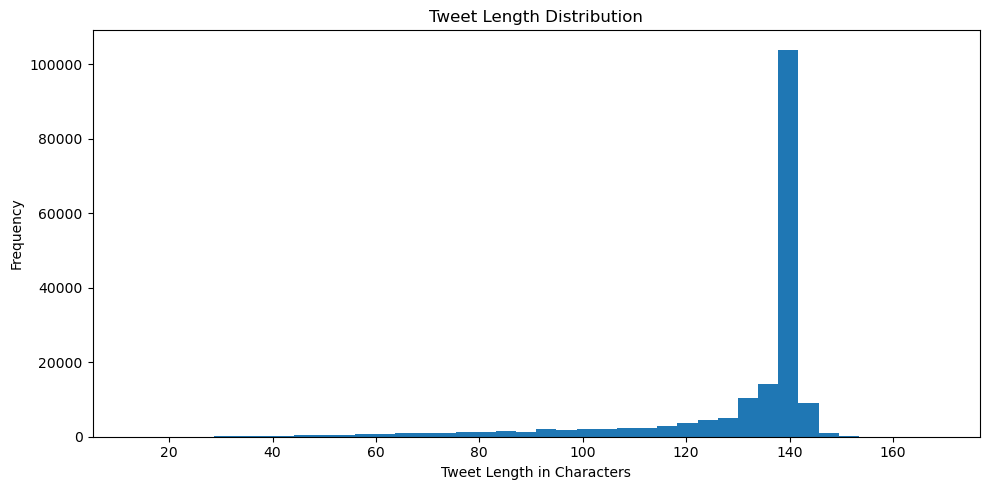

In [14]:
# Tweet length distribution
plt.figure(figsize=(10, 5))
plt.hist(df_clean["tweet_length"], bins=40)
plt.title("Tweet Length Distribution")
plt.xlabel("Tweet Length in Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Hashtag Analysis

Hashtags are important because they organize public discussions and show which topics are most visible in social media conversations.

In [15]:
def parse_hashtags(value):
    if pd.isna(value):
        return []
    value = str(value)
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return [str(tag).lower() for tag in parsed if str(tag).strip()]
    except Exception:
        pass
    value = value.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
    return [tag.strip().lower() for tag in value.split(",") if tag.strip()]

all_hashtags = []
for tags in df_clean["hashtags"].apply(parse_hashtags):
    all_hashtags.extend(tags)

hashtag_counts = Counter(all_hashtags)
top_hashtags = pd.DataFrame(hashtag_counts.most_common(20), columns=["hashtag", "count"])

top_hashtags

,hashtag,count
0,covid19,100312
1,coronavirus,10197
2,pandemic,1625
3,covid,1299
4,india,1193
5,corona,1162
6,trump,1101
7,lockdown,963
8,coronaviruspandemic,882
9,covid_19,828


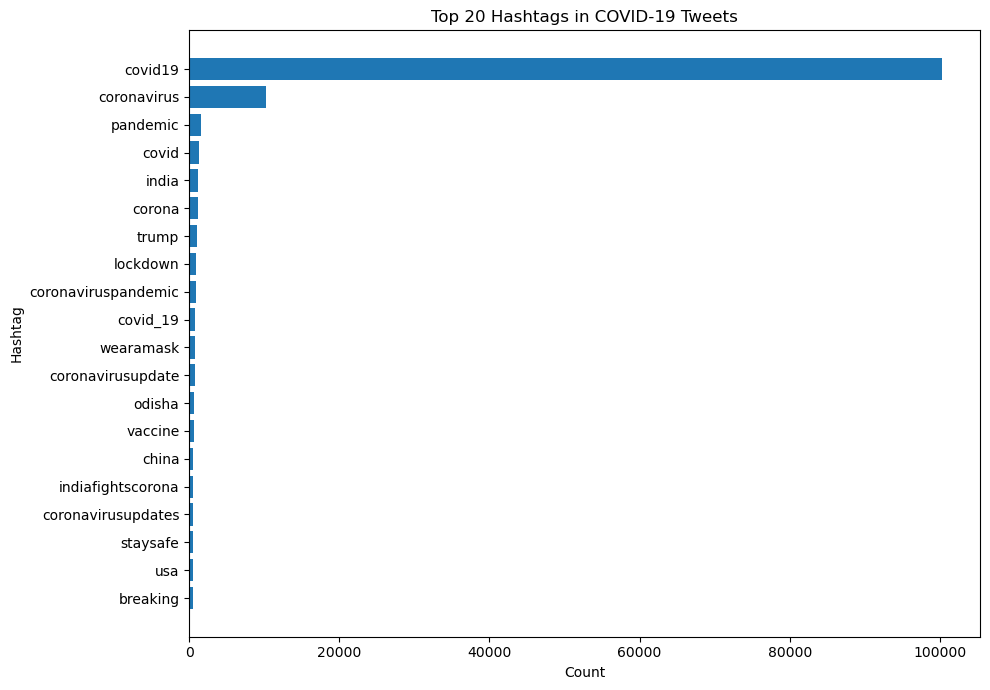

In [16]:
if not top_hashtags.empty:
    plt.figure(figsize=(10, 7))
    plt.barh(top_hashtags["hashtag"][::-1], top_hashtags["count"][::-1])
    plt.title("Top 20 Hashtags in COVID-19 Tweets")
    plt.xlabel("Count")
    plt.ylabel("Hashtag")
    plt.tight_layout()
    plt.show()

## Word Frequency Analysis

Word frequency analysis identifies common terms in the cleaned tweets. Common COVID-19 terms are expected, but this step also helps identify public concerns and repeated themes.

In [17]:
custom_stopwords = {
    "covid", "covid19", "coronavirus", "amp", "rt", "https", "co", "the", "to",
    "of", "and", "in", "for", "is", "on", "this", "that", "with", "from", "are",
    "be", "as", "it", "at", "by", "an", "or"
}

def tokenize_text(text):
    words = str(text).split()
    words = [word for word in words if word not in custom_stopwords and len(word) > 2]
    return words

all_words = []
for text in df_clean["clean_text"]:
    all_words.extend(tokenize_text(text))

word_counts = Counter(all_words)
top_words = pd.DataFrame(word_counts.most_common(25), columns=["word", "count"])
top_words

,word,count
0,you,18904
1,cases,18667
2,new,14714
3,have,14404
4,has,12871
5,your,10636
6,not,9870
7,our,9364
8,people,9055
9,will,8513


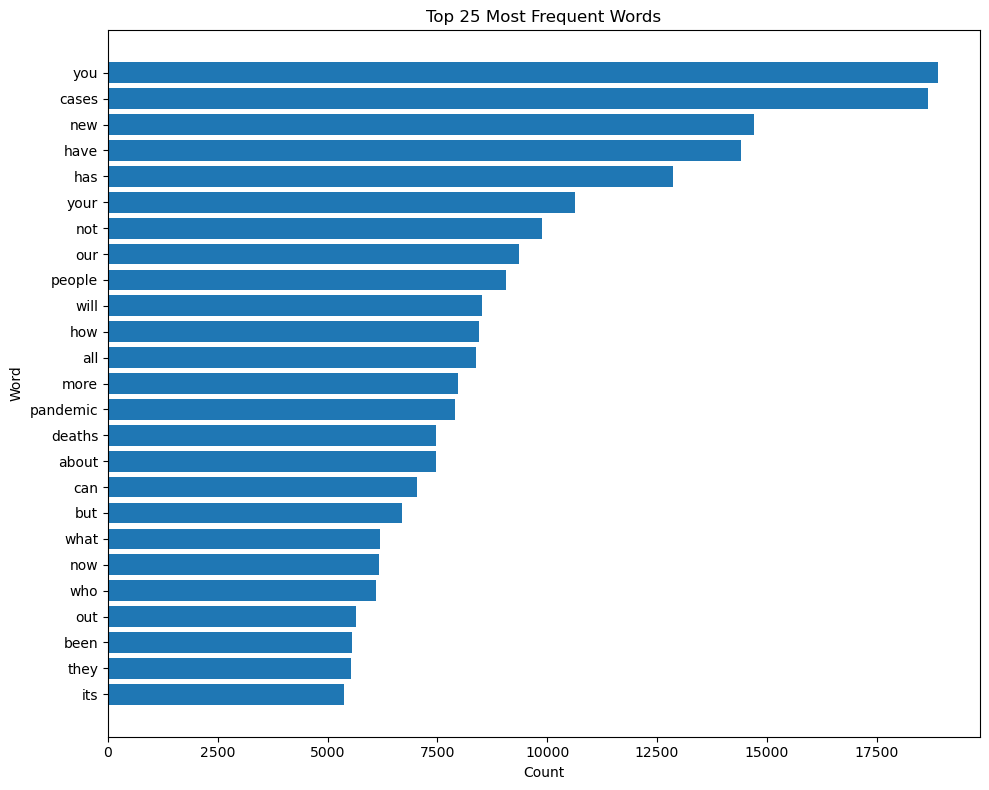

In [18]:
plt.figure(figsize=(10, 8))
plt.barh(top_words["word"][::-1], top_words["count"][::-1])
plt.title("Top 25 Most Frequent Words")
plt.xlabel("Count")
plt.ylabel("Word")
plt.tight_layout()
plt.show()

## Word Cloud

A word cloud provides a visual summary of the most frequent words in the cleaned tweet text.

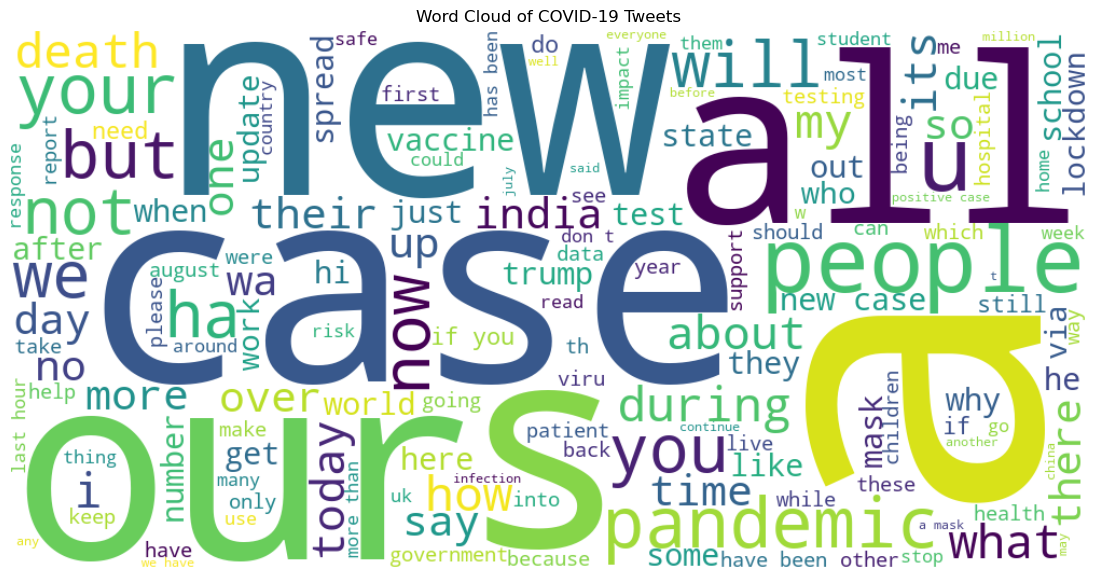

In [19]:
if WordCloud is not None:
    combined_text = " ".join(df_clean["clean_text"].dropna().astype(str).sample(
        min(30000, len(df_clean)), random_state=42
    ))

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white",
        stopwords=custom_stopwords,
        max_words=150
    ).generate(combined_text)

    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of COVID-19 Tweets")
    plt.show()
else:
    print("WordCloud library is not installed.")

## Sentiment Analysis Using TextBlob

Sentiment analysis is used to estimate the emotional tone of each tweet. TextBlob produces a polarity score between -1 and +1. Negative values indicate negative sentiment, positive values indicate positive sentiment, and values close to zero indicate neutral sentiment.

In [20]:
if TextBlob is None:
    raise ImportError("TextBlob is required for this section. Install it with: pip install textblob")

def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def label_sentiment(polarity):
    if polarity > 0.05:
        return "Positive"
    elif polarity < -0.05:
        return "Negative"
    else:
        return "Neutral"

df_clean["polarity"] = df_clean["clean_text"].apply(get_polarity)
df_clean["sentiment"] = df_clean["polarity"].apply(label_sentiment)

df_clean[["text", "clean_text", "polarity", "sentiment"]].head()

,text,clean_text,polarity,sentiment
0,"If I smelled the scent of hand sanitizers today on someone in the past, I would think they were so intoxicated that…...",if i smelled the scent of hand sanitizers today on someone in the past i would think they were so intoxicated that…,-0.25,Negative
1,Hey @Yankees @YankeesPR and @MLB - wouldn't it have made more sense to have the players pay their respects to the A…...,hey and wouldnt it have made more sense to have the players pay their respects to the a…,0.50,Positive
2,@diane3443 @wdunlap @realDonaldTrump Trump never once claimed #COVID19 was a hoax. We all claim that this effort to…...,trump never once claimed covid was a hoax we all claim that this effort to…,0.00,Neutral
3,@brookbanktv The one gift #COVID19 has give me is an appreciation for the simple things that were always around me… ...,the one gift covid has give me is an appreciation for the simple things that were always around me…,0.00,Neutral
4,25 July : Media Bulletin on Novel #CoronaVirusUpdates #COVID19 \n@kansalrohit69 @DrSyedSehrish @airnewsalerts @ANI… ...,july media bulletin on novel coronavirusupdates covid …,0.00,Neutral


In [21]:
sentiment_counts = df_clean["sentiment"].value_counts()
sentiment_percent = (df_clean["sentiment"].value_counts(normalize=True) * 100).round(2)

sentiment_summary = pd.DataFrame({
    "count": sentiment_counts,
    "percent": sentiment_percent
})

sentiment_summary

,count,percent
sentiment,,
Neutral,83424,46.58
Positive,69718,38.93
Negative,25966,14.50


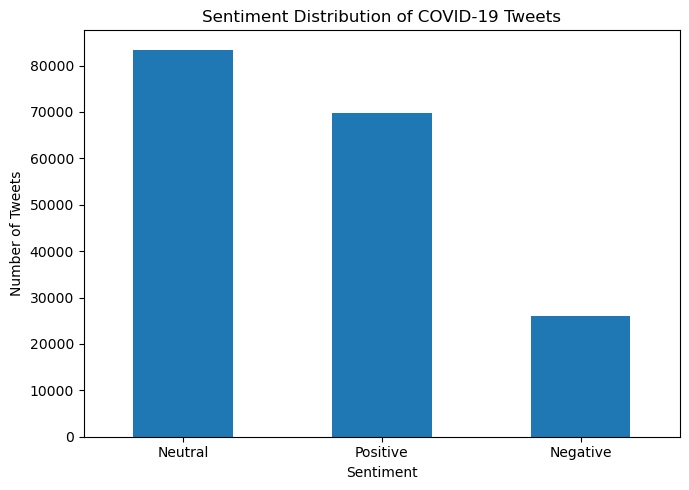

In [22]:
plt.figure(figsize=(7, 5))
sentiment_counts.plot(kind="bar")
plt.title("Sentiment Distribution of COVID-19 Tweets")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

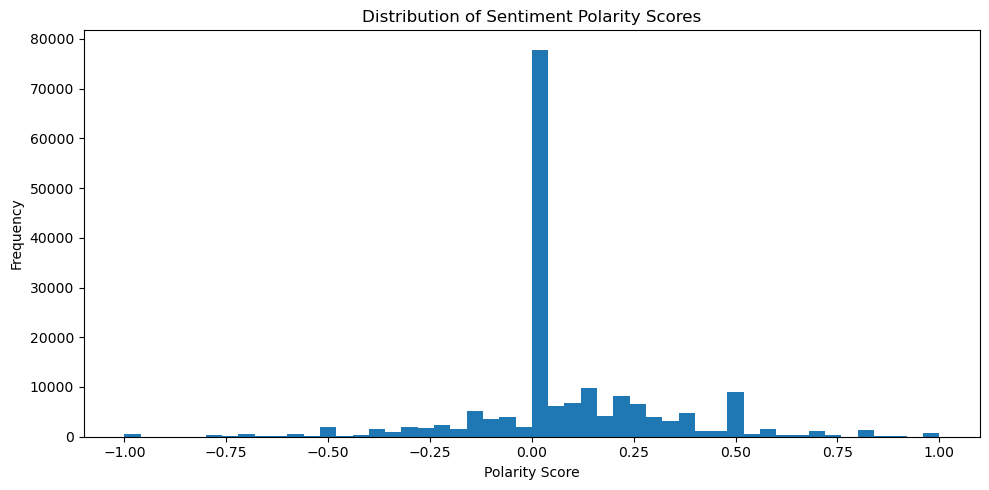

In [23]:
plt.figure(figsize=(10, 5))
plt.hist(df_clean["polarity"], bins=50)
plt.title("Distribution of Sentiment Polarity Scores")
plt.xlabel("Polarity Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## Sentiment Over Time

This analysis shows whether average sentiment changed during the dataset's time period.

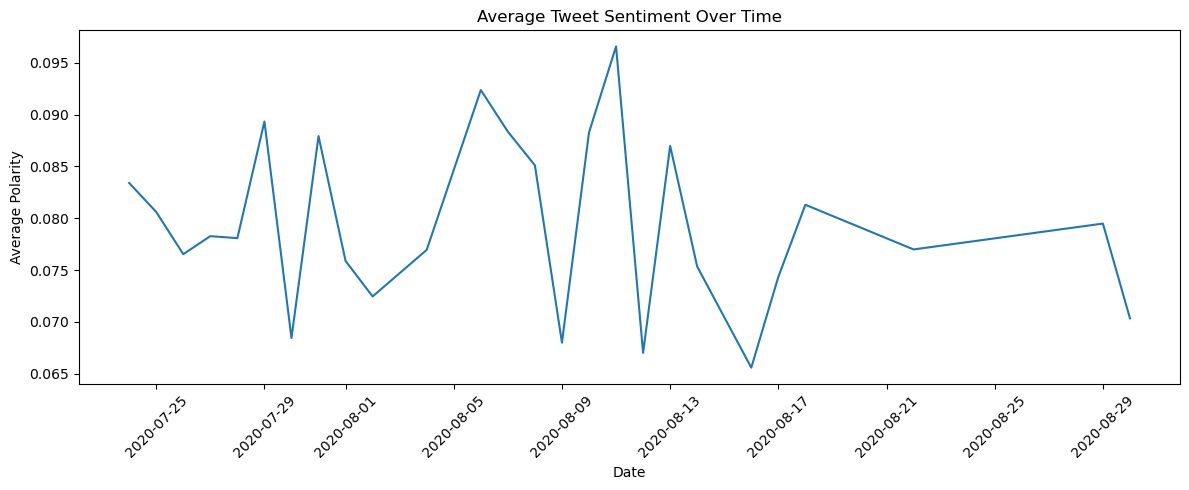

In [24]:
sentiment_over_time = df_clean.groupby("tweet_date")["polarity"].mean()

plt.figure(figsize=(12, 5))
sentiment_over_time.plot()
plt.title("Average Tweet Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Average Polarity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

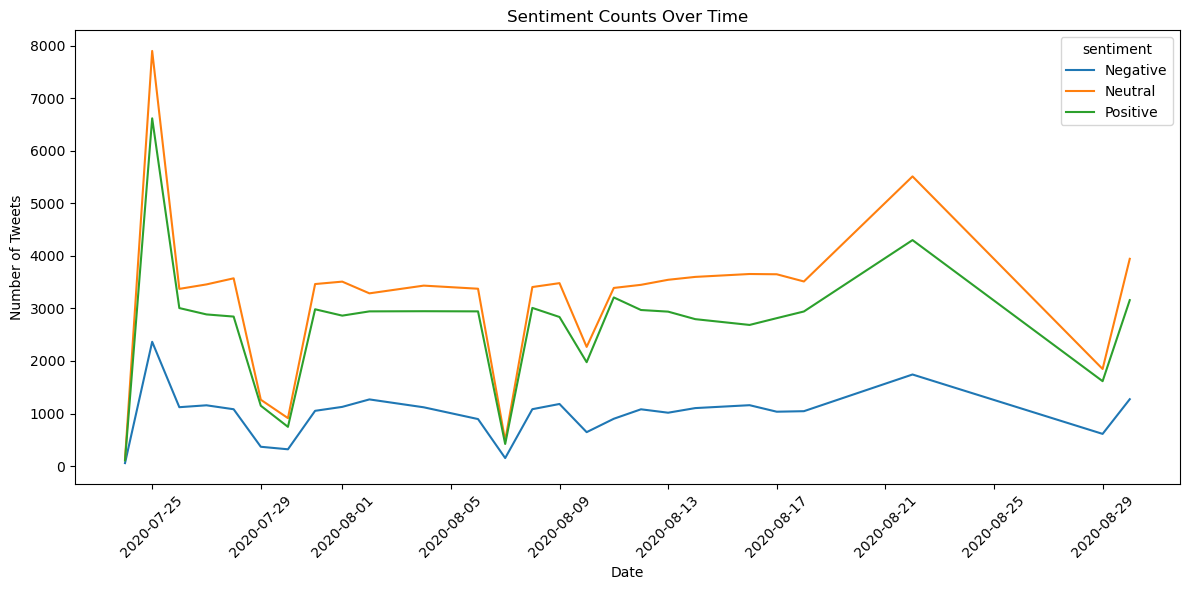

In [25]:
sentiment_by_date = df_clean.groupby(["tweet_date", "sentiment"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sentiment_by_date.plot(figsize=(12, 6))
plt.title("Sentiment Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feature Engineering: TF-IDF

Term Frequency-Inverse Document Frequency (TF-IDF) converts tweet text into numerical features that machine learning models can process. TF-IDF gives higher weight to terms that are frequent in a tweet but not overly common across all tweets.

In [26]:
# Remove empty cleaned tweets
model_df = df_clean[df_clean["clean_text"].str.len() > 0].copy()

# To keep runtime reasonable, sample the data if it is very large.
# Increase this number if your computer can handle more data.
sample_size = min(50000, len(model_df))
model_df = model_df.sample(sample_size, random_state=42)

X_text = model_df["clean_text"]
y = model_df["sentiment"]

vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=3,
    max_df=0.90,
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(X_text)

print("TF-IDF matrix shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

TF-IDF matrix shape: (50000, 5000)
Target distribution:
sentiment
Neutral     23362
Positive    19307
Negative     7331
Name: count, dtype: int64


## Train-Test Split

The dataset is divided into training and testing subsets. The model learns from the training data and is evaluated on the test data.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (40000, 5000)
Testing set: (10000, 5000)


## Machine Learning Model 1: Logistic Regression

Logistic Regression is a strong baseline model for text classification because it performs well with sparse TF-IDF features and is relatively interpretable.

In [28]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    n_jobs=-1
)

log_model.fit(X_train, y_train)
log_predictions = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, log_predictions)
print("Logistic Regression Accuracy:", round(log_accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, log_predictions))

Logistic Regression Accuracy: 0.8508

Classification Report:
              precision    recall  f1-score   support

    Negative       0.69      0.76      0.72      1466
     Neutral       0.86      0.88      0.87      4673
    Positive       0.91      0.85      0.88      3861

    accuracy                           0.85     10000
   macro avg       0.82      0.83      0.82     10000
weighted avg       0.85      0.85      0.85     10000



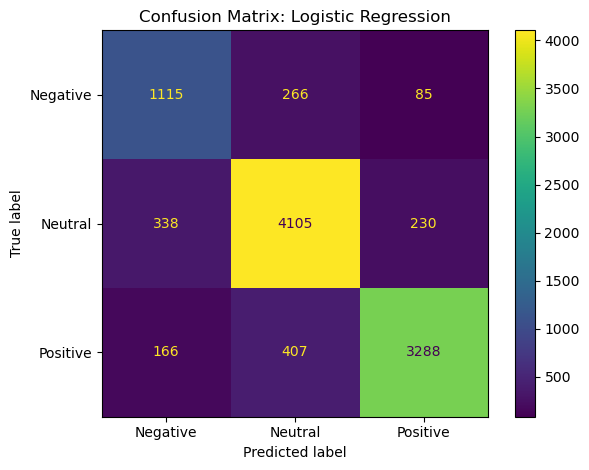

In [29]:
cm_log = confusion_matrix(y_test, log_predictions, labels=log_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=log_model.classes_
)

disp.plot()
plt.title("Confusion Matrix: Logistic Regression")
plt.tight_layout()
plt.show()

## Machine Learning Model 2: Random Forest

Random Forest is included as a comparison model. It can capture nonlinear relationships, but it may be slower and less efficient for large sparse text data than Logistic Regression.

In [30]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
print("Random Forest Accuracy:", round(rf_accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.8569

Classification Report:
              precision    recall  f1-score   support

    Negative       0.82      0.66      0.73      1466
     Neutral       0.84      0.92      0.88      4673
    Positive       0.89      0.86      0.87      3861

    accuracy                           0.86     10000
   macro avg       0.85      0.81      0.83     10000
weighted avg       0.86      0.86      0.85     10000



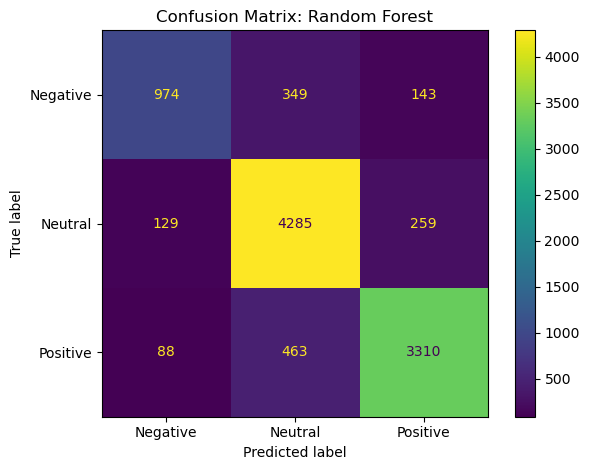

In [31]:
cm_rf = confusion_matrix(y_test, rf_predictions, labels=rf_model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=rf_model.classes_
)

disp.plot()
plt.title("Confusion Matrix: Random Forest")
plt.tight_layout()
plt.show()

## Model Comparison

The table below compares the performance of Logistic Regression and Random Forest. The best model should be selected not only by accuracy, but also by precision, recall, F1-score, interpretability, and runtime.

In [32]:
model_comparison = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "accuracy": [log_accuracy, rf_accuracy]
})

model_comparison

,model,accuracy
0,Logistic Regression,0.8508
1,Random Forest,0.8569


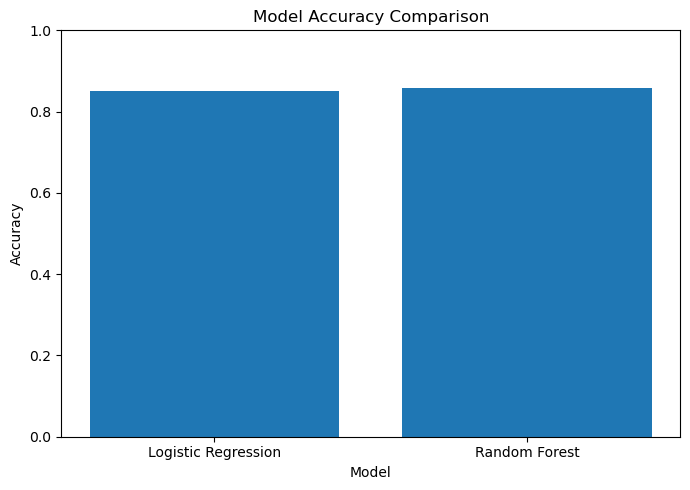

In [33]:
plt.figure(figsize=(7, 5))
plt.bar(model_comparison["model"], model_comparison["accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Interpretation of Results

The analysis provides several important insights:

- The sentiment distribution shows whether COVID-19 related discussion was mostly positive, negative, or neutral.
- Word frequency and hashtag analysis reveal common themes in the public conversation.
- Tweet volume over time shows how public attention changed during the observation period.
- Machine learning models can classify sentiment from tweet text using TF-IDF features.
- Logistic Regression is often a strong model for text classification because it works well with high-dimensional sparse text data.
- Random Forest provides a useful comparison, although it may require more computation and may not always outperform linear models on text data.

These findings suggest that social media can provide useful signals about public awareness and public reaction during health emergencies.

## Ethical Considerations

Using public social media data for health-related analysis requires careful ethical reflection.

First, privacy remains important even when tweets are publicly available. Researchers should avoid exposing personal information, usernames, or identifiable details in reports. This notebook analyzes aggregate patterns rather than focusing on individual users.

Second, social media data may contain sampling bias. Twitter users are not representative of the entire population. People who post frequently may differ from people who do not use social media. Therefore, results should not be generalized to all communities without caution.

Third, sentiment analysis models may misclassify sarcasm, humor, slang, cultural references, and multilingual posts. These errors can affect conclusions if model limitations are not acknowledged.

Fourth, misinformation is a major concern in public health communication. Social media posts may spread inaccurate claims quickly. Data scientists and public health organizations should interpret results responsibly and avoid amplifying misleading content.

Finally, algorithmic bias must be considered. Text processing methods and sentiment tools may perform differently across dialects, languages, and communities. Responsible use of this analysis requires transparency about methods, limitations, and uncertainty.

## Conclusion

This project analyzed COVID-19 related tweets to better understand how social media conversations can reflect public health awareness. The notebook cleaned and prepared tweet data, explored tweet activity patterns, analyzed hashtags and frequent words, estimated sentiment using TextBlob, and developed machine learning models for sentiment classification.

The results show that Twitter data can provide useful insight into public discussion during health events. Sentiment analysis helps summarize public reactions, while visualization techniques reveal trends in tweet activity, hashtags, and common terms. Machine learning models such as Logistic Regression and Random Forest can classify sentiment based on text features, though performance depends on the quality of the text preprocessing and the sentiment labels used.

Overall, social media analytics can support public health communication by helping organizations identify public concerns, monitor changing sentiment, and respond to misinformation. However, findings should be interpreted carefully because social media data is not fully representative and may contain bias, misinformation, or context that automated models cannot fully understand.

## References

Hutto, C. J., & Gilbert, E. (2014). VADER: A parsimonious rule-based model for sentiment analysis of social media text. *Proceedings of the International AAAI Conference on Web and Social Media, 8*(1), 216–225.

Kaggle. (n.d.). *COVID19 tweets dataset*. Kaggle. https://www.kaggle.com/

Loria, S. (2020). *TextBlob: Simplified text processing*. https://textblob.readthedocs.io/

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

World Health Organization. (2020). *Coronavirus disease (COVID-19) pandemic*. https://www.who.int/

Centers for Disease Control and Prevention. (2020). *COVID-19*. https://www.cdc.gov/covid/

## Appendix: Save Cleaned Results

The cleaned dataset with sentiment labels can be saved as a CSV file for use in the final report, presentation, or additional analysis.

In [34]:
output_file = "covid19_tweets_cleaned_sentiment_results.csv"
df_clean.to_csv(output_file, index=False)
print(f"Cleaned dataset saved as {output_file}")

Cleaned dataset saved as covid19_tweets_cleaned_sentiment_results.csv
